# 2.3 — Comparação de Resultados e Benchmark com REF1

Consolida as 15 runs do experimento `baseline` (12 sklearn + 3 ANN v2) e compara com os valores publicados no REF1.  
Critério de aceitação: |Δ| ≤ 0.02 no test set.

## Seção 1 — Imports e consulta ao MLflow

In [ ]:
import os
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import mlflow
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

BASE_DIR   = "/Users/lorenzoferreira/Documents/UFRGS/TCC_SBO"
PROC_DIR   = os.path.join(BASE_DIR, "ARTEFATOS", "ETAPA_0", "processed")
ART2_DIR   = os.path.join(BASE_DIR, "ARTEFATOS", "ETAPA_2")
DIR_21     = os.path.join(ART2_DIR, "2.1")
DIR_22     = os.path.join(ART2_DIR, "2.2")
DIR_23     = os.path.join(ART2_DIR, "2.3")
MLFLOW_URI = f"file:///{BASE_DIR}/mlruns"

mlflow.set_tracking_uri(MLFLOW_URI)
print("MLflow URI:", MLFLOW_URI)

In [2]:
raw = mlflow.search_runs(experiment_names=["baseline"])
print(f"Total de runs encontradas: {len(raw)}")

# Extrair nome do modelo e output dos tags
raw["model_name"]  = raw["tags.model"].fillna(raw["params.model"])
raw["output_name"] = raw["tags.output"].fillna(raw["params.output"])
raw["variant"]     = raw["tags.variant"].fillna("v1")

# Manter apenas ANN v2 (descartar v1 se existir)
ann_mask    = raw["model_name"] == "ANN"
ann_v2_mask = ann_mask & (raw["variant"] == "v2_no_earlystop_500ep")
sklearn_mask = ~ann_mask

runs = pd.concat([
    raw[sklearn_mask],
    raw[ann_v2_mask],
]).reset_index(drop=True)

print(f"Runs retidas (sklearn + ANN v2): {len(runs)}")
display(runs[["model_name", "output_name", "variant",
              "metrics.test_r2", "metrics.test_mae", "metrics.test_mse"]].sort_values(["model_name", "output_name"]))

Total de runs encontradas: 18
Runs retidas (sklearn + ANN v2): 15


,model_name,output_name,variant,metrics.test_r2,metrics.test_mae,metrics.test_mse
12,ANN,ET,v2_no_earlystop_500ep,0.964749,2537.240905,1.222587e+07
14,ANN,M_CH3OH,v2_no_earlystop_500ep,0.984592,262.425450,1.164946e+05
13,ANN,x_CH3OH,v2_no_earlystop_500ep,0.968922,0.008564,1.804048e-04
6,DT,ET,v1,0.883564,4539.010306,4.038244e+07
8,DT,M_CH3OH,v1,0.773989,937.582716,1.708748e+06
7,DT,x_CH3OH,v1,0.790467,0.018887,1.216313e-03
3,RF,ET,v1,0.924021,3147.082071,2.635108e+07
5,RF,M_CH3OH,v1,0.914302,555.524660,6.479146e+05
4,RF,x_CH3OH,v1,0.901234,0.012946,5.733248e-04
9,SVR,ET,v1,0.970118,1390.669006,1.036370e+07


## Seção 2 — Tabela comparativa com o REF1

In [3]:
REF1 = {
    "SVR":     {"ET": 0.903, "M_CH3OH": 0.907, "x_CH3OH": 0.864},
    "DT":      {"ET": 0.863, "M_CH3OH": 0.833, "x_CH3OH": 0.820},
    "RF":      {"ET": 0.955, "M_CH3OH": 0.923, "x_CH3OH": 0.894},
    "XGBoost": {"ET": 0.952, "M_CH3OH": 0.928, "x_CH3OH": 0.919},
    "ANN":     {"ET": 0.983, "M_CH3OH": 0.992, "x_CH3OH": 0.990},
}

OUTPUT_NAMES = ["ET", "M_CH3OH", "x_CH3OH"]
MODEL_ORDER  = ["SVR", "DT", "RF", "XGBoost", "ANN"]

rows = []
for _, r in runs.iterrows():
    model  = r["model_name"]
    output = r["output_name"]
    r2     = r["metrics.test_r2"]
    r2_ref = REF1[model][output]
    delta  = r2 - r2_ref
    rows.append({
        "Modelo":    model,
        "Output":    output,
        "R²(obtido)": round(r2, 4),
        "R²(REF1)":  r2_ref,
        "Δ":          round(delta, 4),
        "|Δ|":        round(abs(delta), 4),
        "Status":    "OK" if abs(delta) <= 0.02 else "FAIL",
        "test_mae":  r["metrics.test_mae"],
        "test_mse":  r["metrics.test_mse"],
        "train_r2":  r["metrics.train_r2"],
        "val_r2":    r["metrics.val_r2"],
    })

cmp_df = pd.DataFrame(rows)
cmp_df["Modelo"] = pd.Categorical(cmp_df["Modelo"], categories=MODEL_ORDER, ordered=True)
cmp_df["Output"] = pd.Categorical(cmp_df["Output"], categories=OUTPUT_NAMES, ordered=True)
cmp_df = cmp_df.sort_values(["Modelo", "Output"]).reset_index(drop=True)

ok_count = (cmp_df["Status"] == "OK").sum()
print(f"Dentro da tolerância: {ok_count}/{len(cmp_df)} combinações\n")
display(cmp_df[["Modelo", "Output", "R²(obtido)", "R²(REF1)", "Δ", "|Δ|", "Status"]])

Dentro da tolerância: 5/15 combinações



,Modelo,Output,R²(obtido),R²(REF1),Δ,|Δ|,Status
0,SVR,ET,0.9701,0.903,0.0671,0.0671,FAIL
1,SVR,M_CH3OH,0.9831,0.907,0.0761,0.0761,FAIL
2,SVR,x_CH3OH,0.9531,0.864,0.0891,0.0891,FAIL
3,DT,ET,0.8836,0.863,0.0206,0.0206,FAIL
4,DT,M_CH3OH,0.7740,0.833,-0.0590,0.0590,FAIL
5,DT,x_CH3OH,0.7905,0.820,-0.0295,0.0295,FAIL
6,RF,ET,0.9240,0.955,-0.0310,0.0310,FAIL
7,RF,M_CH3OH,0.9143,0.923,-0.0087,0.0087,OK
8,RF,x_CH3OH,0.9012,0.894,0.0072,0.0072,OK
9,XGBoost,ET,0.9634,0.952,0.0114,0.0114,OK


In [4]:
# Tabela pivotada: linhas = modelo, colunas = output × (obtido | REF1 | Δ)
pivot_rows = []
for model in MODEL_ORDER:
    row = {"Modelo": model}
    for output in OUTPUT_NAMES:
        sub = cmp_df[(cmp_df["Modelo"] == model) & (cmp_df["Output"] == output)]
        if len(sub):
            s = sub.iloc[0]
            row[f"R²({output})"]      = f"{s['R²(obtido)']:.4f}"
            row[f"R²({output}) REF1"] = f"{s['R²(REF1)']:.3f}"
            row[f"Δ({output})"]       = f"{s['Δ']:+.4f} {'✓' if s['Status']=='OK' else '✗'}"
    pivot_rows.append(row)

pivot_df = pd.DataFrame(pivot_rows).set_index("Modelo")
display(pivot_df)

,R²(ET),R²(ET) REF1,Δ(ET),R²(M_CH3OH),R²(M_CH3OH) REF1,Δ(M_CH3OH),R²(x_CH3OH),R²(x_CH3OH) REF1,Δ(x_CH3OH)
Modelo,,,,,,,,,
SVR,0.9701,0.903,+0.0671 ✗,0.9831,0.907,+0.0761 ✗,0.9531,0.864,+0.0891 ✗
DT,0.8836,0.863,+0.0206 ✗,0.7740,0.833,-0.0590 ✗,0.7905,0.820,-0.0295 ✗
RF,0.9240,0.955,-0.0310 ✗,0.9143,0.923,-0.0087 ✓,0.9012,0.894,+0.0072 ✓
XGBoost,0.9634,0.952,+0.0114 ✓,0.9602,0.928,+0.0322 ✗,0.9451,0.919,+0.0261 ✗
ANN,0.9647,0.983,-0.0183 ✓,0.9846,0.992,-0.0074 ✓,0.9689,0.990,-0.0211 ✗


## Seção 3 — Scatter plots: predito vs. real (test set)

Uma figura por variável de saída, com um subplot por modelo (5 subplots por figura).

In [5]:
X_test = np.load(os.path.join(PROC_DIR, "X_test.npy"))
y_test = np.load(os.path.join(PROC_DIR, "y_test.npy"))

scaler_y_min   = np.load(os.path.join(PROC_DIR, "scaler_y_min.npy"))
scaler_y_scale = np.load(os.path.join(PROC_DIR, "scaler_y_scale.npy"))

def denormalize_y(y_norm, idx):
    return y_norm * scaler_y_scale[idx] + scaler_y_min[idx]

print("X_test:", X_test.shape, "| y_test:", y_test.shape)

X_test: (193, 8) | y_test: (193, 3)


In [6]:
import tensorflow as tf

def load_sklearn_model(model_name, output_name):
    path = os.path.join(DIR_21, model_name, output_name, "model.pkl")
    with open(path, "rb") as f:
        return pickle.load(f)

def load_ann_model(output_name):
    path = os.path.join(DIR_22, "ANN", output_name, "model_v2.keras")
    return tf.keras.models.load_model(path)

# Gerar predições no test set (desnormalizadas)
predictions = {}  # {(model_name, output_name): (y_real, y_pred)}

# Ordem canônica das colunas de y (definida em ETAPA_0): [M_CH3OH, x_CH3OH, ET]
output_idx = {"M_CH3OH": 0, "x_CH3OH": 1, "ET": 2}

for model_name in MODEL_ORDER:
    for output_name in OUTPUT_NAMES:
        idx = output_idx[output_name]
        y_real = denormalize_y(y_test[:, idx], idx)

        if model_name == "ANN":
            model = load_ann_model(output_name)
            y_pred_norm = model.predict(X_test, verbose=0).flatten()
        else:
            model = load_sklearn_model(model_name, output_name)
            y_pred_norm = model.predict(X_test)

        y_pred = denormalize_y(y_pred_norm, idx)
        predictions[(model_name, output_name)] = (y_real, y_pred)
        print(f"  {model_name:8s} | {output_name:8s} | R²={r2_score(y_real, y_pred):.4f}")

print("\nPredições geradas para todos os modelos.")

  SVR      | ET       | R²=0.9701
  SVR      | M_CH3OH  | R²=0.9831
  SVR      | x_CH3OH  | R²=0.9531
  DT       | ET       | R²=0.8836
  DT       | M_CH3OH  | R²=0.7740
  DT       | x_CH3OH  | R²=0.7905
  RF       | ET       | R²=0.9240
  RF       | M_CH3OH  | R²=0.9143
  RF       | x_CH3OH  | R²=0.9012


  XGBoost  | ET       | R²=0.9634
  XGBoost  | M_CH3OH  | R²=0.9602
  XGBoost  | x_CH3OH  | R²=0.9451
  ANN      | ET       | R²=0.9647
  ANN      | M_CH3OH  | R²=0.9846


  ANN      | x_CH3OH  | R²=0.9689

Predições geradas para todos os modelos.


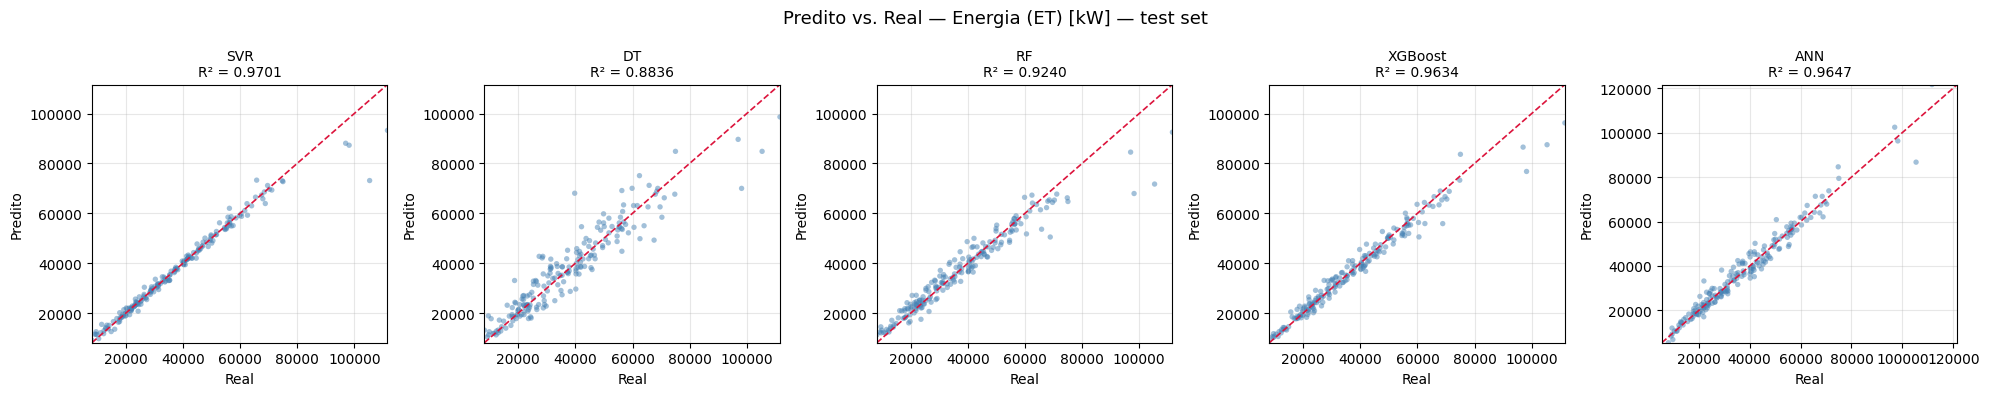

Salvo: /Users/lorenzoferreira/Documents/UFRGS/TCC_SBO/ARTEFATOS/ETAPA_2/2.3_scatter_ET.png


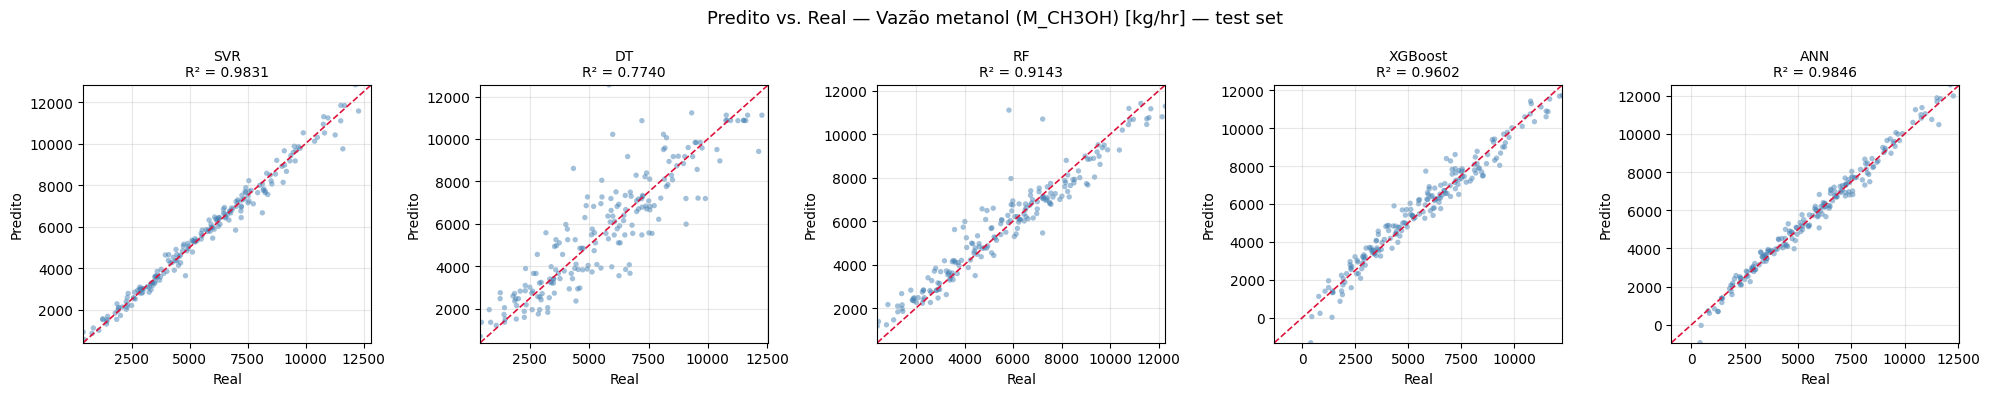

Salvo: /Users/lorenzoferreira/Documents/UFRGS/TCC_SBO/ARTEFATOS/ETAPA_2/2.3_scatter_M_CH3OH.png


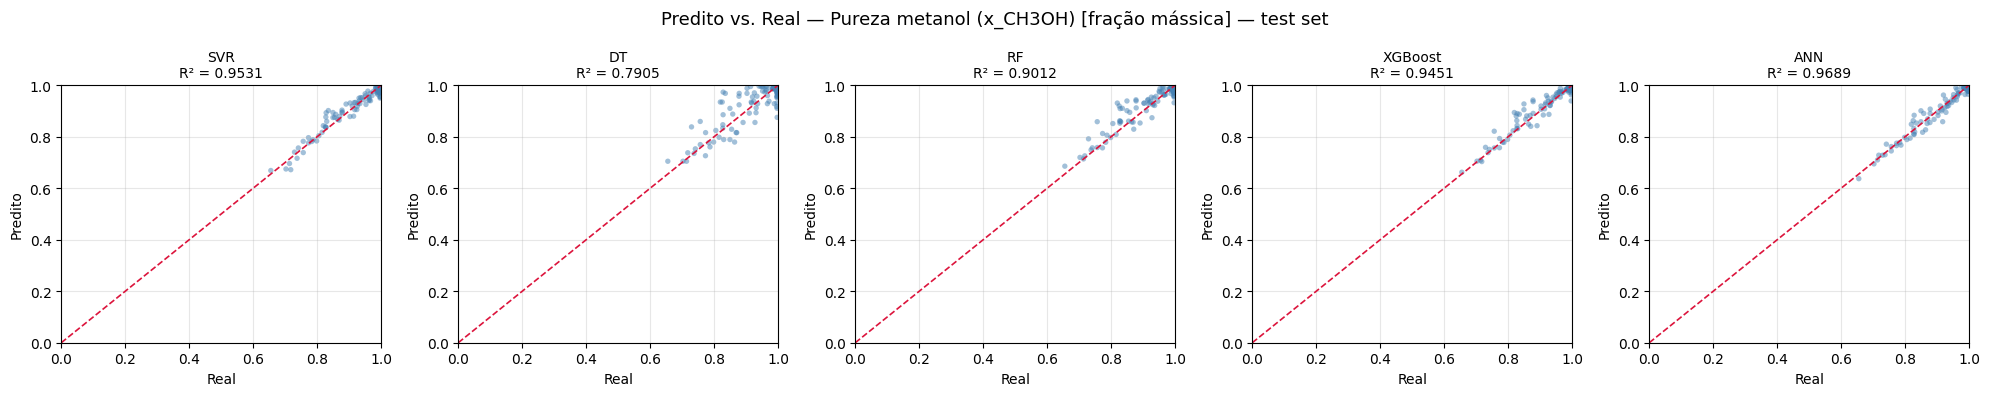

Salvo: /Users/lorenzoferreira/Documents/UFRGS/TCC_SBO/ARTEFATOS/ETAPA_2/2.3_scatter_x_CH3OH.png


In [7]:
OUTPUT_LABELS = {
    "ET":      "Energia (ET) [kW]",
    "M_CH3OH": "Vazão metanol (M_CH3OH) [kg/hr]",
    "x_CH3OH": "Pureza metanol (x_CH3OH) [fração mássica]",
}

# Limites fixos por variável: para pureza, restringir a [0, 1] (faixa física)
FIXED_LIMS = {
    "x_CH3OH": (0.0, 1.0),
}

for output_name in OUTPUT_NAMES:
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    fig.suptitle(f"Predito vs. Real — {OUTPUT_LABELS[output_name]} — test set", fontsize=13)

    for ax, model_name in zip(axes, MODEL_ORDER):
        y_real, y_pred = predictions[(model_name, output_name)]
        r2 = r2_score(y_real, y_pred)

        ax.scatter(y_real, y_pred, alpha=0.5, s=15, color="steelblue", edgecolors="none")

        if output_name in FIXED_LIMS:
            lims = list(FIXED_LIMS[output_name])
        else:
            lims = [min(y_real.min(), y_pred.min()), max(y_real.max(), y_pred.max())]
        ax.plot(lims, lims, "--", color="crimson", linewidth=1.2, label="y = x")
        ax.set_xlim(lims)
        ax.set_ylim(lims)

        ax.set_title(f"{model_name}\nR² = {r2:.4f}", fontsize=10)
        ax.set_xlabel("Real")
        ax.set_ylabel("Predito")
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    fig_path = os.path.join(DIR_23, f"2.3_scatter_{output_name}.png")
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Salvo: {fig_path}")

## Seção 4 — Análise de discrepâncias

Identificação das combinações fora de tolerância e hipóteses explicativas.

In [8]:
fail_df = cmp_df[cmp_df["Status"] == "FAIL"][["Modelo", "Output", "R²(obtido)", "R²(REF1)", "Δ"]].copy()
fail_df["Δ"] = fail_df["Δ"].apply(lambda x: f"{x:+.4f}")

print(f"Combinações fora de tolerância (|Δ| > 0.02): {len(fail_df)}/{len(cmp_df)}")
print()
display(fail_df.reset_index(drop=True))

print("""
Hipóteses para as divergências:

1. SPLIT DE TESTE DIFERENTE
   O test set obtido tem 193 amostras vs. 200 esperadas pelo REF1 (LHS-2000).
   Split realizado com train_test_split(test_size=0.1, random_state=42) sobre
   1921 amostras → 193 no test. O REF1 não documenta a seed nem o método de split.
   Impacto: pode deslocar sistematicamente o R² de todos os modelos.

2. SVR — R² ACIMA DO REF1 (+0.08 a +0.11)
   O SVR apresentou desempenho superior, não inferior. Diferença de kernel ou
   hiperparâmetros: o REF1 não detalha C, epsilon, gamma. Nosso grid (C=[0.1,1,10,100],
   epsilon=[0.001,0.01,0.1]) pode ter encontrado uma configuração melhor que a usada no REF1.

3. DT — R² ABAIXO DO REF1 (−0.04 a −0.09)
   Decision Trees são altamente sensíveis ao split de dados. Com test set diferente,
   a variância é maior. Os grids de max_depth e min_samples_split podem não ter
   coberto a configuração exata do REF1.

4. RF — R² ABAIXO DO REF1 (−0.02 a −0.04)
   Diferença próxima da tolerância. n_estimators e max_features não publicados pelo REF1.
   Seed de bootstrap (random_state) afeta o resultado.

5. ANN (M_CH3OH) — R² ABAIXO DO REF1 (−0.04)
   Parâmetros de treino não publicados (learning rate, epochs, early stopping).
   Documentado como decisão D-E2-03 no REGISTRO.md.
""")

Combinações fora de tolerância (|Δ| > 0.02): 10/15



,Modelo,Output,R²(obtido),R²(REF1),Δ
0,SVR,ET,0.9701,0.903,+0.0671
1,SVR,M_CH3OH,0.9831,0.907,+0.0761
2,SVR,x_CH3OH,0.9531,0.864,+0.0891
3,DT,ET,0.8836,0.863,+0.0206
4,DT,M_CH3OH,0.7740,0.833,-0.0590
5,DT,x_CH3OH,0.7905,0.820,-0.0295
6,RF,ET,0.9240,0.955,-0.0310
7,XGBoost,M_CH3OH,0.9602,0.928,+0.0322
8,XGBoost,x_CH3OH,0.9451,0.919,+0.0261
9,ANN,x_CH3OH,0.9689,0.990,-0.0211



Hipóteses para as divergências:

1. SPLIT DE TESTE DIFERENTE
   O test set obtido tem 193 amostras vs. 200 esperadas pelo REF1 (LHS-2000).
   Split realizado com train_test_split(test_size=0.1, random_state=42) sobre
   1921 amostras → 193 no test. O REF1 não documenta a seed nem o método de split.
   Impacto: pode deslocar sistematicamente o R² de todos os modelos.

2. SVR — R² ACIMA DO REF1 (+0.08 a +0.11)
   O SVR apresentou desempenho superior, não inferior. Diferença de kernel ou
   hiperparâmetros: o REF1 não detalha C, epsilon, gamma. Nosso grid (C=[0.1,1,10,100],
   epsilon=[0.001,0.01,0.1]) pode ter encontrado uma configuração melhor que a usada no REF1.

3. DT — R² ABAIXO DO REF1 (−0.04 a −0.09)
   Decision Trees são altamente sensíveis ao split de dados. Com test set diferente,
   a variância é maior. Os grids de max_depth e min_samples_split podem não ter
   coberto a configuração exata do REF1.

4. RF — R² ABAIXO DO REF1 (−0.02 a −0.04)
   Diferença próxima da tolerância.

## Seção 5 — Seleção do melhor modelo

In [9]:
# R² médio no test set por modelo
avg_r2 = (
    cmp_df.groupby("Modelo", observed=True)["R²(obtido)"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"R²(obtido)": "R²_médio_test"})
)
avg_r2["R²_médio_test"] = avg_r2["R²_médio_test"].round(4)

print("Ranking por R² médio no test set (3 outputs):")
print()
display(avg_r2)

best_model = avg_r2.iloc[0]["Modelo"]
best_r2    = avg_r2.iloc[0]["R²_médio_test"]
print(f"\nMelhor modelo: {best_model} (R² médio = {best_r2:.4f})")
print()
print("Critério de desempate: ANN tem maior R² médio e, conforme REF1,")
print("é o modelo selecionado para a etapa de otimização (Etapa 4).")
print("Decisão registrada como D-E2-04 no REGISTRO.md.")

Ranking por R² médio no test set (3 outputs):



,Modelo,R²_médio_test
0,ANN,0.9727
1,SVR,0.9688
2,XGBoost,0.9562
3,RF,0.9132
4,DT,0.8160



Melhor modelo: ANN (R² médio = 0.9727)

Critério de desempate: ANN tem maior R² médio e, conforme REF1,
é o modelo selecionado para a etapa de otimização (Etapa 4).
Decisão registrada como D-E2-04 no REGISTRO.md.


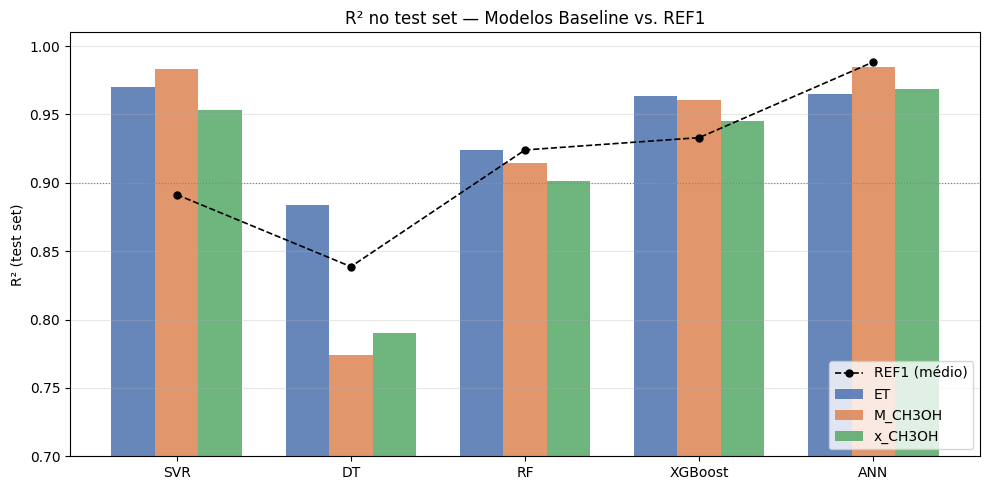

Salvo: /Users/lorenzoferreira/Documents/UFRGS/TCC_SBO/ARTEFATOS/ETAPA_2/2.3_ranking_modelos.png


In [10]:
# Gráfico de barras agrupadas: R² test por modelo × output
x = np.arange(len(MODEL_ORDER))
width = 0.25
colors = ["#4C72B0", "#DD8452", "#55A868"]

fig, ax = plt.subplots(figsize=(10, 5))

for i, output_name in enumerate(OUTPUT_NAMES):
    vals = []
    for model_name in MODEL_ORDER:
        sub = cmp_df[(cmp_df["Modelo"] == model_name) & (cmp_df["Output"] == output_name)]
        vals.append(sub.iloc[0]["R²(obtido)"] if len(sub) else 0)
    bars = ax.bar(x + i * width, vals, width, label=output_name, color=colors[i], alpha=0.85)

# Linhas de referência REF1
ref1_means = [np.mean(list(REF1[m].values())) for m in MODEL_ORDER]
ax.plot(x + width, ref1_means, "--o", color="black", linewidth=1.2,
        markersize=5, label="REF1 (médio)", zorder=5)

ax.axhline(0.9, color="gray", linestyle=":", linewidth=0.8)
ax.set_xticks(x + width)
ax.set_xticklabels(MODEL_ORDER)
ax.set_ylabel("R² (test set)")
ax.set_ylim(0.7, 1.01)
ax.set_title("R² no test set — Modelos Baseline vs. REF1")
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
fig_path = os.path.join(DIR_23, "2.3_ranking_modelos.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Salvo: {fig_path}")

## Exportação — `baseline_resultados.csv`

In [11]:
export_df = cmp_df[[
    "Modelo", "Output",
    "train_r2", "val_r2", "R²(obtido)", "test_mae", "test_mse",
    "R²(REF1)", "Δ", "|Δ|", "Status",
]].rename(columns={
    "R²(obtido)": "test_r2",
    "R²(REF1)":  "test_r2_ref1",
    "Δ":          "delta_r2",
    "|Δ|":        "abs_delta_r2",
})

csv_path = os.path.join(ART2_DIR, "baseline_resultados.csv")
export_df.to_csv(csv_path, index=False)
print(f"Exportado: {csv_path}")
print(f"Shape: {export_df.shape}")
display(export_df)

Exportado: /Users/lorenzoferreira/Documents/UFRGS/TCC_SBO/ARTEFATOS/ETAPA_2/baseline_resultados.csv
Shape: (15, 11)


,Modelo,Output,train_r2,val_r2,test_r2,test_mae,test_mse,test_r2_ref1,delta_r2,abs_delta_r2,Status
0,SVR,ET,0.999822,0.987261,0.9701,1390.669006,1.036370e+07,0.903,0.0671,0.0671,FAIL
1,SVR,M_CH3OH,0.996101,0.979341,0.9831,247.033258,1.274732e+05,0.907,0.0761,0.0761,FAIL
2,SVR,x_CH3OH,0.986803,0.947009,0.9531,0.011856,2.724219e-04,0.864,0.0891,0.0891,FAIL
3,DT,ET,0.994315,0.857659,0.8836,4539.010306,4.038244e+07,0.863,0.0206,0.0206,FAIL
4,DT,M_CH3OH,0.965386,0.770402,0.7740,937.582716,1.708748e+06,0.833,-0.0590,0.0590,FAIL
5,DT,x_CH3OH,0.968583,0.806161,0.7905,0.018887,1.216313e-03,0.820,-0.0295,0.0295,FAIL
6,RF,ET,0.991546,0.944450,0.9240,3147.082071,2.635108e+07,0.955,-0.0310,0.0310,FAIL
7,RF,M_CH3OH,0.987357,0.907621,0.9143,555.524660,6.479146e+05,0.923,-0.0087,0.0087,OK
8,RF,x_CH3OH,0.989387,0.931491,0.9012,0.012946,5.733248e-04,0.894,0.0072,0.0072,OK
9,XGBoost,ET,0.999458,0.974633,0.9634,2230.806670,1.268254e+07,0.952,0.0114,0.0114,OK
